In [1]:
from hexgrid import HexCoord, HexGrid, build_obstacle_map, VelocityState
from hexstar import HStarProblem, HStarSearch, h_cost_travel_time, construct_full_solution, BidHStarSearch, calculate_path_smoothness, Node
from hexplot import plot_hex_grid_2, axial_to_xy

In [2]:
import matplotlib.pyplot as plt
from typing import Iterable, Optional

In [3]:
center = HexCoord(0,0)
start = HexCoord(-2,1)
goal = HexCoord(3,-4)
radius = 15
hex_size = 0.3
seed = 0
num_obs = 10

a_max = 3 # acceleration ability
a_min = 1 # deceleration ability
a_lat = 7 # maximum lateral g-force allowed by the agent

<Axes: >

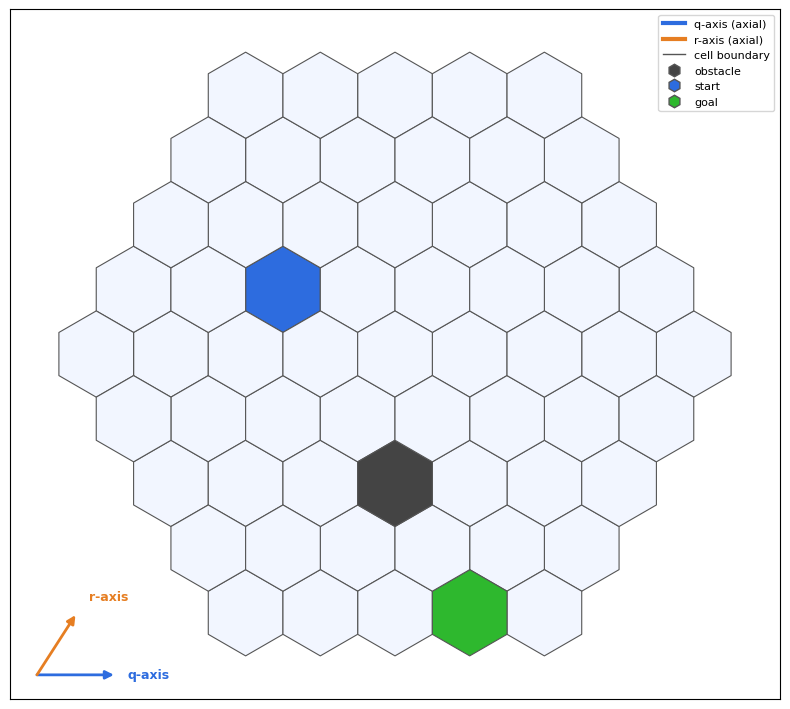

In [13]:
obstacles = {HexCoord(1,-2)}
hex_grid = HexGrid(hex_size, obstacles)

start_v = VelocityState(0, 0) # 0 speed, unspecified direction (allows expansion in any direction at root)
goal_v = VelocityState(0, None) # matches any direction as long as location matches. 

problem = HStarProblem(
    hex_grid,
    start,
    goal,
    a_max,  
    a_min,  
    start_v = start_v,
    goal_v = goal_v,
    collision_radius = 0,
    heuristic = h_cost_travel_time,
    n_step = 1,
    
)

search = HStarSearch(problem)

plot_hex_grid_2(
    obstacles=problem.grid.obstacles,
    start=problem.start,
    goal=problem.goal,
    center=center,
    radius=4,
    #figsize=figsize,
    #path=successors,
    #cell_styles=cell_styles,
    #facecolor_path=successor_color,
    #ax=ax,
    #plt_title=f"Expansion {iteration}",
    #axis_corner=axis_corner,
    #show_axis_legend=show_legend,
)

In [14]:
def plot_expansion_iteration(
    problem: HStarProblem,
    search: HStarSearch,
    expansion_path: Iterable[HexCoord],
    iteration: int,
    center: HexCoord,
    radius: int = 4,
    ax: Optional[plt.Axes] = None,
    figsize: tuple[float, float] = (7, 7),
    current_color: str = "#0072B2",
    path_color: str = "#808080",
    next_candidate_color: str = "#CC79A7",
    successor_color: str = "#E69F00",
    axis_corner: str = "lower left",
    show_legend: bool = True,
) -> tuple[Node, set[HexCoord], plt.Axes]:
    """
    Follow a specified expansion branch and plot one expansion iteration.

    The plot shows:
      - the original start node
      - the current selected path
      - the node currently being expanded
      - successors generated during the current iteration
      - the successor selected for expansion in the next iteration

    expansion_path excludes the root coordinate.

    For example:
        expansion_path = [
            HexCoord(2, 0),  # current node in iteration 2
            HexCoord(4, 0),  # current node in iteration 3
            HexCoord(5, 1),  # current node in iteration 4
        ]
    """
    if iteration < 1:
        raise ValueError("iteration must be at least 1")
    expansion_path = list(expansion_path)
    required_coordinates = iteration - 1

    if len(expansion_path) < required_coordinates:
        raise ValueError(
            f"Iteration {iteration} requires at least "
            f"{required_coordinates} coordinates in expansion_path, "
            f"but only {len(expansion_path)} were provided."
        )

    # Iteration 1 expands the root.
    current_node = search.root

    # These are the selected coordinates leading to the current node.
    selected_path = expansion_path[:required_coordinates]

    # Build the Node parent chain through the selected path.
    for path_index, selected_coord in enumerate(selected_path):
        valid_successors = set(problem.actions(current_node))

        if selected_coord not in valid_successors:
            valid_successors_sorted = sorted(
                valid_successors,
                key=lambda cell: (cell.q, cell.r),
            )

            raise ValueError(
                f"{selected_coord} is not a valid successor of "
                f"{current_node.location} while constructing "
                f"iteration {path_index + 2}.\n"
                f"Valid successors: {valid_successors_sorted}"
            )

        current_node = problem.result(
            current_node,
            selected_coord,
        )

    # Generate successors only for the current iteration.
    successors = set(problem.actions(current_node))

    # Determine which successor is selected for the next iteration.
    next_candidate = None

    if required_coordinates < len(expansion_path):
        next_candidate = expansion_path[required_coordinates]

        if next_candidate not in successors:
            valid_successors_sorted = sorted(
                successors,
                key=lambda cell: (cell.q, cell.r),
            )

            raise ValueError(
                f"Next candidate {next_candidate} is not a valid "
                f"successor of {current_node.location} during "
                f"iteration {iteration}.\n"
                f"Valid successors: {valid_successors_sorted}"
            )

    cell_styles = {}

    # Color the selected path leading to the current node.
    # The start remains controlled by the standard start color.
    for path_cell in selected_path:
        if (
            path_cell != problem.start
            and path_cell != current_node.location
        ):
            cell_styles[path_cell] = (
                path_color,
                "current path",
            )

    # Color the node currently being expanded.
    if current_node.location != problem.start:
        cell_styles[current_node.location] = (
            current_color,
            "current node",
        )

    # Color the candidate selected for the next expansion.
    # This assignment comes last so it replaces the successor overlay.
    if next_candidate is not None:
        cell_styles[next_candidate] = (
            next_candidate_color,
            "next expansion",
        )

    ax = plot_hex_grid_2(
        obstacles=problem.grid.obstacles,
        start=problem.start,
        goal=problem.goal,
        center=center,
        radius=radius,
        figsize=figsize,
        path=successors,
        cell_styles=cell_styles,
        facecolor_path=successor_color,
        ax=ax,
        plt_title=f"Expansion {iteration}",
        axis_corner=axis_corner,
        show_axis_legend=show_legend,
    )

    return current_node, successors, ax

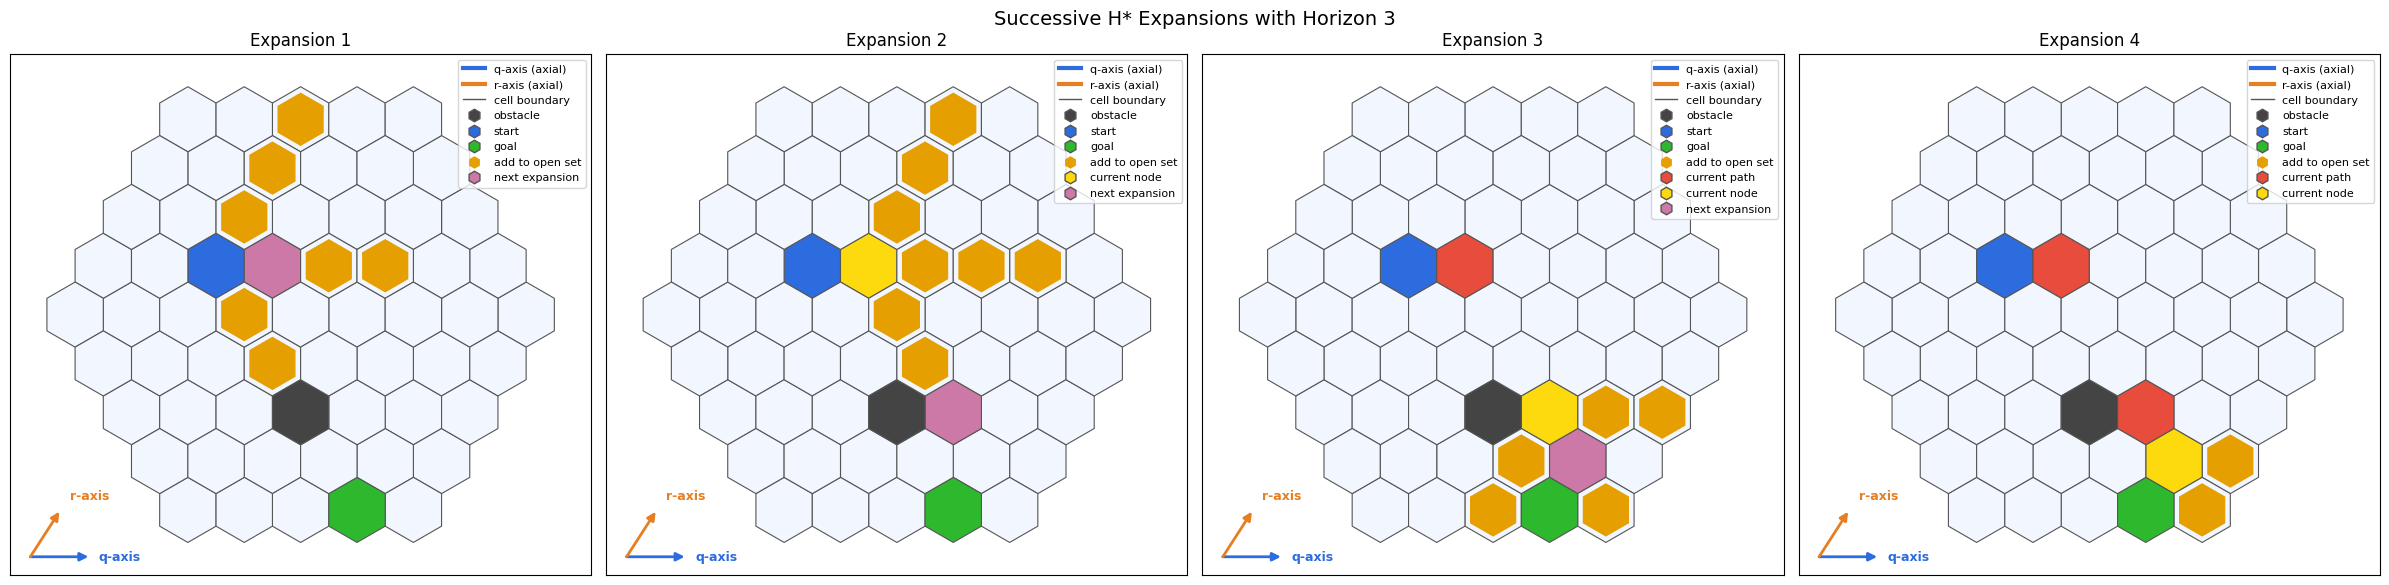

In [7]:
expansion_path = [
    HexCoord(-1, 1),
    HexCoord(2, -2),
    HexCoord(3, -3),
]
number_of_iterations = len(expansion_path) + 1

fig, axes = plt.subplots(
    1,
    number_of_iterations,
    figsize=(6 * number_of_iterations, 6),
    sharex=True,
    sharey=True,
    squeeze=False,
)

axes = axes.ravel()

for iteration, ax in enumerate(axes, start=1):
    plot_expansion_iteration(
        problem=problem,
        search=search,
        expansion_path=expansion_path,
        iteration=iteration,
        center=center,
        radius=4,
        ax=ax,
        current_color="#FDDA0D",
        path_color="#e74c3c",
        next_candidate_color="#CC79A7",
        successor_color="#E69F00",
        axis_corner="lower left",
        #show_legend=(iteration == number_of_iterations),
    )

fig.suptitle(
    f"Successive H* Expansions with Horizon 3",
    fontsize=14,
)

fig.tight_layout()

fig.savefig(
    "hstar_expansion_sequence.png",
    bbox_inches="tight",
)

plt.show()